Adding an average pooling layer to reduce model size


**Performance:** 
- nearly 100% on d0.00
- takes about 3k batches
```
Total params: 42,506,307
Trainable params: 18,717,699
Non-trainable params: 23,788,608
----------------------------------------------------------------
Input size (MB): 1.83
Forward/backward pass size (MB): 1373.79
Params size (MB): 162.15
Estimated Total Size (MB): 1537.77
```

**Model:**
ImageNet1k_v2
- training resnet [-2][-2:] and [-1]
- adaptive avg pooling layer
- one dense layer with xyz output

**Training:**
- Batch size 96
- MSE loss
- Adam, learning rate 0.001


In [1]:
import numpy as np
from training_data import load_training_data
import matplotlib.pyplot as plt

In [2]:
save_path = "torch_models/02_avg_pooling.pth"
training_data_path = "training_data"

In [3]:
all_training_data = load_training_data(training_data_path)
levels = list(all_training_data.levels.keys())

# The training data loaded above is a MultiLevelTrainingData instance.
# Choose a single level to train on:
training_level = 'd0.00'
training_data = all_training_data.get_level(training_level)

# disable normalization; we'll do that later
training_data.input_norm = None
training_data.output_norm = None

Best so far:
batch size 96
resnet101v2
    - training all of resnet[-1] and resnet[-2][-3:]
adaptive avg pool 2d (1, 1)
lr 0.001

In [4]:
# training_data.generator(batch_size) returns a generator that yields batches of training data.
# each example is a tuple (input, output) where input is a 3D numpy array of shape (batch_size, height, width)
# and output is a 2D numpy array of shape (batch_size, 3*onehot_vector_size). Each output contains 3 one-hot vectors
# representing the x, y, and z coordinates of the target. For now, we will ignore the z axis.

# Build a pytorch model consisting of:
# - a resnet101v2 pretrained on imagenet, excluding its final classification layer
#    (the final layer has output shape (batch_size, M, N, channels)
# - a max pooling layer that takes the maximum only over channels (output shape (batch_size, M, N))
# - a dense layer with 3 one-hot outputs (output shape (batch_size, 3, onehot_size))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

print("CUDA:", torch.cuda.is_available())

class PipetteDetector(nn.Module):
    def __init__(self):
        super(PipetteDetector, self).__init__()
        resnet101 = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        self.resnet = torch.nn.Sequential(*(list(resnet101.children())[:-2]))

        # freeze all parameters in the resnet
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # unfreeze the last block (10 layers)
        # for param in self.resnet[-1][-1].parameters():
        #     param.requires_grad = True

        # unfreeze thelast 6th-4rd blocks (30 layers) 
        for i in range(3):
            for param in self.resnet[-2][-i].parameters():
                param.requires_grad = True
        
        # unfreeze the last 3 blocks (30 layers)
        for param in self.resnet[-1].parameters():
            param.requires_grad = True
            
        # global average pooling 2d
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        # self.pooling = nn.AdaptiveMaxPool2d((1, 1))

        # max pooling 2d
        # self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)
        # self.pooling = nn.AvgPool2d(kernel_size=2, stride=2)

        # self.layers = torch.nn.Sequential(
        #     nn.LazyConv2d(4, kernel_size=3, stride=1, padding=1),
        #     nn.ReLU(),
        #     nn.LazyConv2d(8, kernel_size=7, stride=1, padding=3),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        # )

        # If output size is currently (channels, height, width), add a convolutional layer with kernel size (height, 1) and output size (1, onehot_size)
        # output_shape = (13, 13)
        # self.x_conv = nn.LazyConv2d((onehot_size // output_shape[1]) + 1, kernel_size=(output_shape[0], 1))
        # self.y_conv = nn.LazyConv2d((onehot_size // output_shape[0]) + 1, kernel_size=(1, output_shape[1]))
        # self.z_conv = nn.LazyConv2d((onehot_size // output_shape[0]) + 1, kernel_size=(1, output_shape[1]))

        self.xyz_out = nn.LazyLinear(3)

    def forward(self, input):
        resnet_output = self.resnet(input)

        # x = self.x_conv(resnet_output)
        # y = self.y_conv(resnet_output)
        # # flatten x and y
        # x = x.reshape(x.size(0), -1)
        # y = y.reshape(y.size(0), -1)
        # # crop to onehot_size
        # x = x[:, :onehot_size]
        # y = y[:, :onehot_size]

        pooled = self.pooling(resnet_output)

        flat = pooled.reshape(pooled.size(0), -1)
        # flat = input.reshape(input.size(0), -1)
        # flat = resnet_output.reshape(resnet_output.size(0), -1)

        # output = self.layers(input)
        # flat = output.reshape(output.size(0), -1)
        xyz = self.xyz_out(flat)
        return xyz
    
# initialize a model just to see its structure
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CUDA: True


In [5]:
from torchsummary import summary
test_model = PipetteDetector()
test_model.to(device);
# print(model)
summary(test_model, input_size=(3, 400, 400))

del test_model
torch.cuda.empty_cache()


/home/luke/pipette-detection/conda_env/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 200, 200]           9,408
       BatchNorm2d-2         [-1, 64, 200, 200]             128
              ReLU-3         [-1, 64, 200, 200]               0
         MaxPool2d-4         [-1, 64, 100, 100]               0
            Conv2d-5         [-1, 64, 100, 100]           4,096
       BatchNorm2d-6         [-1, 64, 100, 100]             128
              ReLU-7         [-1, 64, 100, 100]               0
            Conv2d-8         [-1, 64, 100, 100]          36,864
       BatchNorm2d-9         [-1, 64, 100, 100]             128
             ReLU-10         [-1, 64, 100, 100]               0
           Conv2d-11        [-1, 256, 100, 100]          16,384
      BatchNorm2d-12        [-1, 256, 100, 100]             512
           Conv2d-13        [-1, 256, 100, 100]          16,384
      BatchNorm2d-14        [-1, 256, 1

In [6]:
# prepare training data
from training_data import Normalizer

# decide how to transform data
img_normalizer = lambda x: (x / 255).transpose((0, 3, 1, 2)).astype(np.float32)
pos_normalizer = Normalizer(range=[[-100, 0, 0], [100, 500, 500]])
def make_image_tensor(data):
    """Convert ubyte image data to a 0.0-1.0 float32 torch tensor on the GPU."""
    return torch.tensor(img_normalizer(data)).to(device)
def make_position_tensor(data):
    """Convert position data to a normalized (-0.5 to 0.5) float32 torch tensor on the GPU."""
    return torch.tensor(pos_normalizer.normalize(data).astype(np.float32)).to(device)

batch_size = 96
data_generator = training_data.generator(batch_size)
# data_generator yields batches of (image, position) data
#  - images are 3D numpy arrays of shape (batch_size, height, width), with values in [0, 255]
#  - positions are 2D numpy arrays of shape (batch_size, (z, y, x)), with z values in microns and x, y in pixels 

# prepare validation data
n_validation_batches = 4
validation_data = [next(data_generator) for i in range(n_validation_batches)]
validation_images = make_image_tensor(np.concatenate([x[0] for x in validation_data]))
validation_positions = make_position_tensor(np.concatenate([x[1] for x in validation_data]))

In [7]:
# initialize the model
model = PipetteDetector()
model.to(device)

# Define a loss function and optimizer
criterion = nn.MSELoss()  # for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

def analyze_prediction(predicted_pos, target_pos, radius=0.02):
    predicted_pos = predicted_pos.cpu().detach().clone().numpy()
    target_pos = target_pos.cpu().detach().clone().numpy()
    result = {
        'rmse_xy': ((predicted_pos - target_pos)[:, 1:3]**2).mean()**0.5,
        'rmse_z': ((predicted_pos - target_pos)[:, 0]**2).mean()**0.5,
        'n_correct_xy': (((predicted_pos - target_pos)[:, 1:3]**2).sum(axis=1)**0.5 < radius).sum(),
        'batch_size': predicted_pos.shape[0],
    }
    result['accuracy_xy'] = result['n_correct_xy'] / result['batch_size']
    return result


[step 000009] avg sqrt loss: 0.167558
              final sqrt loss: 0.116490
              val sqrt loss: 0.100105
              training xy accuracy: 1.15%
              validation xy accuracy: 1.30%

[step 000019] avg sqrt loss: 0.078228
              final sqrt loss: 0.060287
              val sqrt loss: 0.057720
              training xy accuracy: 2.71%
              validation xy accuracy: 4.69%

[step 000029] avg sqrt loss: 0.049496
              final sqrt loss: 0.036789
              val sqrt loss: 0.040984
              training xy accuracy: 7.19%
              validation xy accuracy: 8.33%

[step 000039] avg sqrt loss: 0.041133
              final sqrt loss: 0.037233
              val sqrt loss: 0.034730
              training xy accuracy: 10.42%
              validation xy accuracy: 14.84%

[step 000049] avg sqrt loss: 0.035283
              final sqrt loss: 0.030614
              val sqrt loss: 0.031148
              training xy accuracy: 13.96%
              validation xy

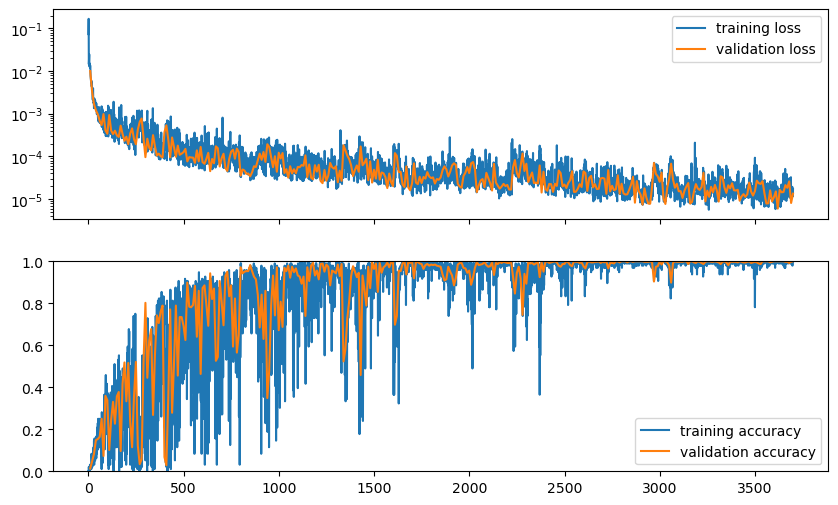

In [8]:

# Train the model
class TrainingHistory:
    def __init__(self):
        self.history = {'i': [], 'loss': []}

    def append(self, i, prediction, target, loss):
        self.history['i'].append(i)
        self.history['loss'].append(loss)
        result = analyze_prediction(prediction, target)
        for k,v in result.items():
            if k not in self.history:
                self.history[k] = []
            self.history[k].append(v)

    def __getitem__(self, key):
        return np.array(self.history[key])
    
    def plot(self, loss_ax, accuracy_ax, label=None):
        loss_ax.plot(self.history['i'], self.history['loss'], label=label+' loss')
        loss_ax.set_yscale('log')
        loss_ax.legend()
        accuracy_ax.plot(self.history['i'], self.history['accuracy_xy'], label=label+' accuracy')
        accuracy_ax.set_ylim(0, 1)
        accuracy_ax.legend()


training_history = TrainingHistory()
validation_history = TrainingHistory()
try:
    for i, data in enumerate(data_generator):
        # inputs is a 4D numpy array of shape (batch_size, height, width, channels), normalized to [0, 1]
        # labels is a 2D numpy array of shape (batch_size, 3), normalized using training_data.output_norm
        inputs, labels = data
        image_tensor = make_image_tensor(inputs)
        position_tensor = make_position_tensor(labels)

        # zero the parameter gradients (otherwise they accumulate)
        optimizer.zero_grad()

        # run model, calculate loss, and backpropagate
        output = model(image_tensor)
        loss = criterion(output, position_tensor)
        loss.backward()
        optimizer.step()
        # scheduler.step()

        # track performance over time
        training_history.append(i, output, position_tensor, loss.item())
        del image_tensor, position_tensor, output, loss
        torch.cuda.empty_cache()

        if i % 10 == 9:
            with torch.no_grad():
                val_output = model(validation_images)
                val_loss = criterion(val_output, validation_positions)
                validation_history.append(i, val_output, validation_positions, val_loss.item())

            recent_size = 10
            training_loss = training_history['loss'][-recent_size:]
            training_accuracy = training_history['accuracy_xy'][-recent_size:].mean()
            val_loss = validation_history['loss'][-1]
            validation_accuracy = validation_history['accuracy_xy'][-1]
            print(
                f'[step {i:06d}] avg sqrt loss: {(training_loss**0.5).mean():0.6f}\n'
                f'              final sqrt loss: {training_loss[-1]**0.5:0.6f}\n'
                f'              val sqrt loss: {val_loss**0.5:0.6f}\n'
                f'              training xy accuracy: {100 * training_accuracy:0.2f}%\n'
                f'              validation xy accuracy: {100 * validation_accuracy:0.2f}%\n'
            )
            del val_output, val_loss
            torch.cuda.empty_cache()
            
        if i % 100 == 99:
            print("Saving model..")
            torch.save(model.state_dict(), save_path)

except KeyboardInterrupt:
    print('Interrupted, saving..')
    torch.save(model.state_dict(), save_path)

print('Finished Training')

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
training_history.plot(ax[0], ax[1], label='training')
validation_history.plot(ax[0], ax[1], label='validation')


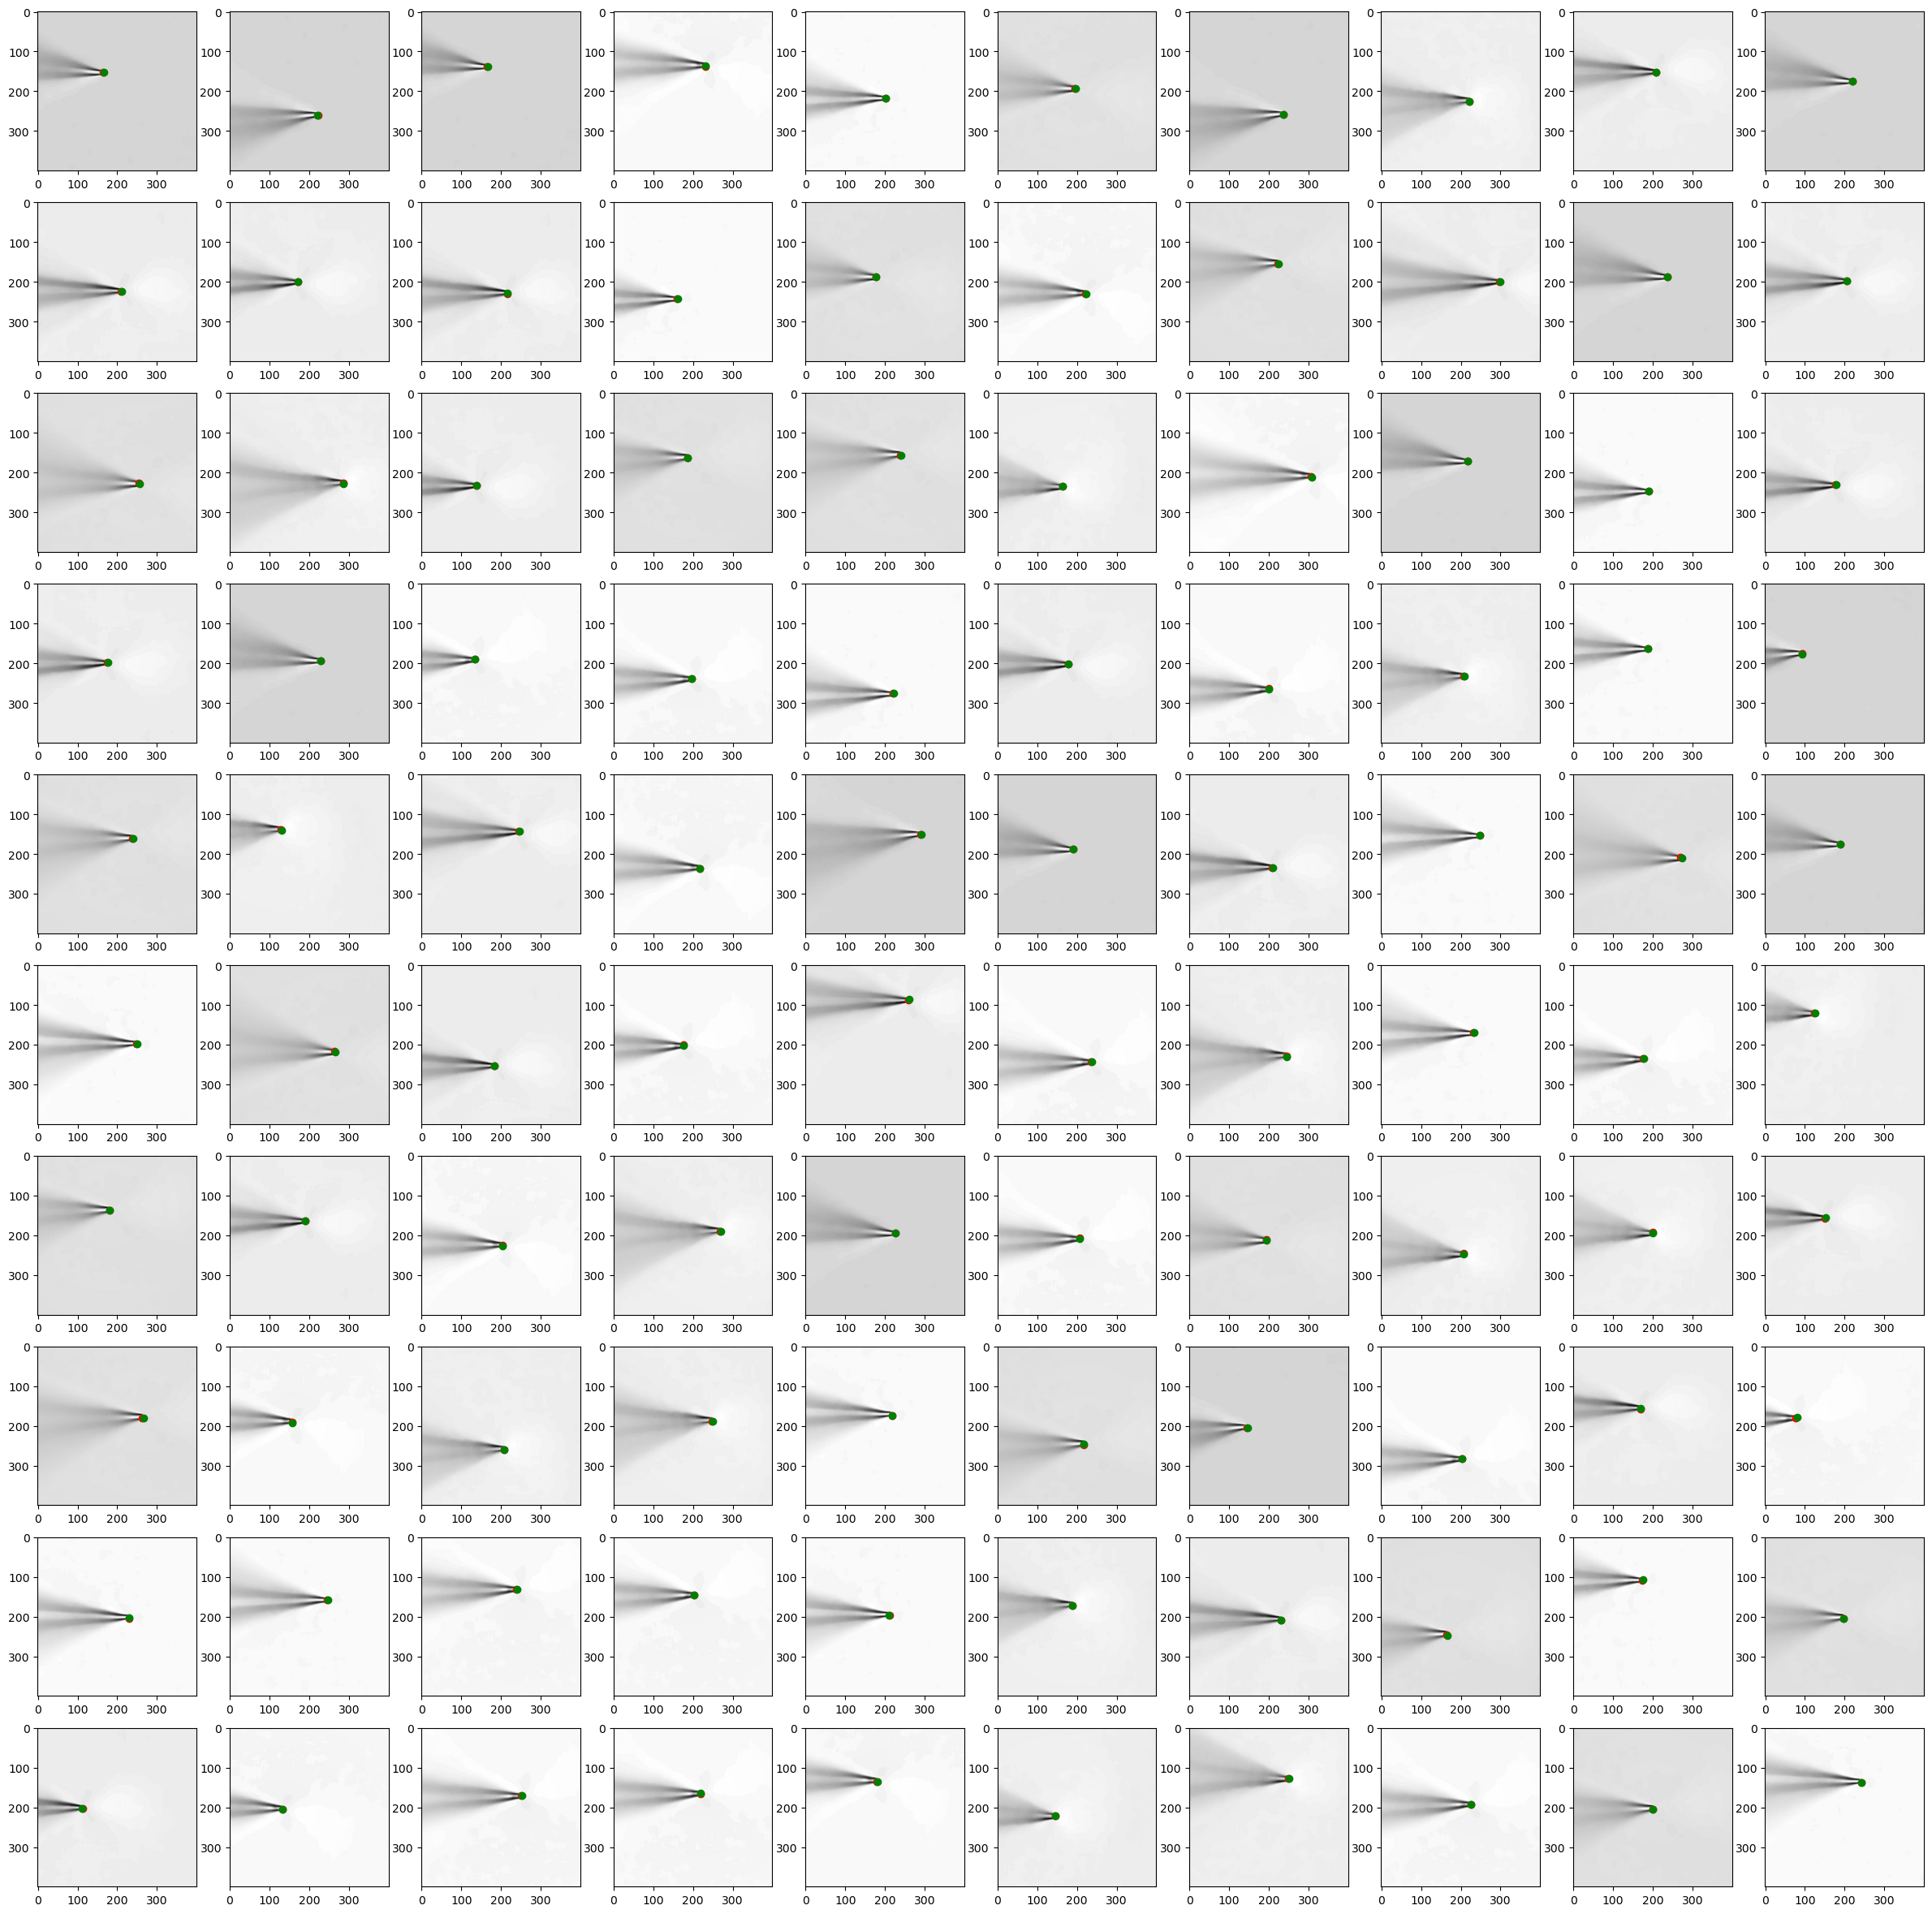

In [9]:
shape = (10, 10)
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

image, pip_pos = training_data[:shape[0]*shape[1]].get_arrays()
# pip_pos = training_data.output_norm.denormalize(pip_pos)
# use model in inference mode to make prediction from image
model.eval()
with torch.no_grad():
    image_tensor = make_image_tensor(image)
    pred = model(image_tensor).cpu().numpy()
    pred = pos_normalizer.denormalize(pred)


for i, axi in enumerate(ax.flatten()):
    # pred = training_data.output_norm.denormalize(model.model.predict(image))
    axi.imshow(image[i], cmap='gray')
    axi.scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
    axi.scatter(pred[i, 2], pred[i, 1], color='green')

